# 04 – RNN / LSTM language models

Vanilla (tanh) RNN and LSTM next-word models in PyTorch (`src/rnn.py`), compared with the n-gram models of `03_ngram.ipynb` under **identical conditions**:

- same vocabulary (`data/processed/vocab.json`), same loader (`src/data.py`), same evaluator (`src/evaluate.py`);
- **context = the current sentence only**: every sentence is run through the network from a zero state at `<s>` (the n-gram main comparison);
- whole sentences are batched (bucketed by length, right-padded, loss masked) and **never truncated**;
- the output softmax covers the whole vocabulary including `<s>`, which is never a target – exactly like the n-gram models, whose floor also gives `<s>` a tiny non-zero probability; perplexity is over **all** tokens (incl. `</s>`, `<unk>`, `<num>`, punctuation).

**Training recipe (both models):** embedding size = hidden size with tied input/output embeddings; dropout on the embeddings, between layers and before the output layer; Adam (lr 1e-3); `ReduceLROnPlateau` on validation perplexity (factor 0.5, patience 1); gradient clipping at norm 1.0; early stopping with patience 3; at most 30 epochs; seed 42.

**Selection:** the LSTM is tuned on validation only over hidden {256, 512} × layers {1, 2} × dropout {0.3, 0.5} (the full grid fits the budget: 10–20 s per epoch on the RTX 4050). The vanilla RNN gets the best LSTM's hidden size and layer count (dropout 0.3 / 0.5 both tried, best on validation kept). The ensemble is `P = λ·P_LSTM + (1−λ)·P_KN3` with λ tuned on validation in steps of 0.1. **Test set: evaluated once** for the best RNN, best LSTM and the ensemble.

Training is done by `python -m src.train_rnn` (checkpoints in `models/*.pt`, log in `models/rnn_train.log`); this notebook loads the checkpoints (it would train a missing run itself).

In [1]:
import os, sys, json, pickle, random, re, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import data as D, evaluate as E, rnn as R, generate as G

DRY = os.environ.get("NB_DRY") == "1"          # dry run: score VALIDATION instead of test, log nothing
EVAL_SPLIT = "val" if DRY else "test"
LOG = not DRY
FIG_DIR, TAB_DIR, MODEL_DIR = ROOT / "figures", ROOT / "tables", ROOT / "models"
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 200, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
BLUE, ORANGE, GREEN, GREY = "#0072B2", "#D55E00", "#009E73", "#777777"
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, torch.cuda.get_device_name(0) if device == "cuda" else "", "| evaluation split:", EVAL_SPLIT, "| DRY RUN" if DRY else "")


def save_fig(fig, name):
    fig.savefig(FIG_DIR / name, dpi=200, bbox_inches="tight")
    print(f"saved figure -> figures/{name}")


def save_table(df, name, index=False):
    df.to_csv(TAB_DIR / name, index=index, encoding="utf-8")
    print(f"saved table  -> tables/{name}")


vocab = D.load_vocab()
V = len(vocab)
train = D.load_split("train", vocab=vocab)
val = D.load_split("val", vocab=vocab)
METRICS = ROOT / "results" / "metrics.csv"
if LOG and METRICS.exists():                    # re-running the notebook must not duplicate its own rows
    old = pd.read_csv(METRICS)
    old[~old["model"].astype(str).str.match(r"^(lstm_|rnn_|ensemble)")].to_csv(METRICS, index=False)


def mb(path):
    return Path(path).stat().st_size / 1e6


# parameter count / size on disk of every n-gram model (pickles from 03_ngram.ipynb): "parameters" = stored n-gram types
ngram_info = {}
for name in ["unigram", "laplace2", "laplace3", "kn2", "kn3", "kn4", "kn5"]:
    m = pickle.load(open(MODEL_DIR / f"{name}.pkl", "rb"))
    ngram_info[name] = {"params": m.num_ngrams(), "size_mb": mb(MODEL_DIR / f"{name}.pkl")}
if LOG and METRICS.exists():                    # fill the new columns of the earlier n-gram rows
    mt = pd.read_csv(METRICS)
    for name, info in ngram_info.items():
        sel = mt["model"] == name
        mt.loc[sel, "params"], mt.loc[sel, "size_mb"] = info["params"], round(info["size_mb"], 2)
    mt.to_csv(METRICS, index=False)
pd.DataFrame(ngram_info).T.round(2)

device: cuda NVIDIA GeForce RTX 4050 Laptop GPU | evaluation split: test 


,params,size_mb
unigram,14712.0,0.12
laplace2,239035.0,3.34
laplace3,564421.0,14.42
kn2,253747.0,3.58
kn3,818168.0,17.99
kn4,1546000.0,44.43
kn5,2317836.0,75.88


## 1. LSTM grid (validation only)

In [2]:
def cfg_of(cell, hidden, layers, dropout):
    return R.default_cfg(cell=cell, hidden=hidden, layers=layers, dropout=dropout)


def load(cfg):
    model, ck = R.train_or_load(cfg, train, val, V, device)
    return model, ck


rows, runs = [], {}
for hidden in (256, 512):
    for layers in (1, 2):
        for dropout in (0.3, 0.5):
            cfg = cfg_of("lstm", hidden, layers, dropout)
            model, ck = load(cfg)
            runs[R.run_name(cfg)] = (cfg, model, ck)
            h = ck["history"]
            rows.append({"run": R.run_name(cfg), "hidden": hidden, "layers": layers, "dropout": dropout,
                         "params": ck["num_params"], "epochs_run": len(h), "best_epoch": ck["best_epoch"],
                         "best_val_ppl": round(ck["best_val_ppl"], 2),
                         "train_ppl_eval_at_best": round(h[ck["best_epoch"] - 1]["train_ppl_eval"], 1),
                         "sec_per_epoch": round(np.mean([x["seconds"] for x in h]), 1)})
grid = pd.DataFrame(rows).sort_values("best_val_ppl").reset_index(drop=True)
display(grid)
save_table(grid, "rnn_lstm_grid.csv")
best_lstm_name = grid.loc[0, "run"]
best_cfg = runs[best_lstm_name][0]
print("best LSTM on validation:", best_lstm_name)

loaded lstm_h256_l1_d0.3 (best epoch 22, val ppl 106.84)
loaded lstm_h256_l1_d0.5 (best epoch 30, val ppl 104.97)
loaded lstm_h256_l2_d0.3 (best epoch 26, val ppl 107.84)
loaded lstm_h256_l2_d0.5 (best epoch 30, val ppl 109.57)


loaded lstm_h512_l1_d0.3 (best epoch 9, val ppl 103.84)
loaded lstm_h512_l1_d0.5 (best epoch 13, val ppl 99.85)


loaded lstm_h512_l2_d0.3 (best epoch 13, val ppl 103.20)
loaded lstm_h512_l2_d0.5 (best epoch 15, val ppl 100.34)


,run,hidden,layers,dropout,params,epochs_run,best_epoch,best_val_ppl,train_ppl_eval_at_best,sec_per_epoch
0,lstm_h512_l1_d0.5,512,1,0.5,9649017,16,13,99.85,60.1,19.1
1,lstm_h512_l2_d0.5,512,2,0.5,11750265,18,15,100.34,67.3,19.6
2,lstm_h512_l2_d0.3,512,2,0.3,11750265,16,13,103.20,59.1,21.5
3,lstm_h512_l1_d0.3,512,1,0.3,9649017,12,9,103.84,60.7,17.4
4,lstm_h256_l1_d0.5,256,1,0.5,4307577,30,30,104.97,68.7,10.1
5,lstm_h256_l1_d0.3,256,1,0.3,4307577,25,22,106.84,64.0,10.0
6,lstm_h256_l2_d0.3,256,2,0.3,4833913,29,26,107.84,72.9,11.3
7,lstm_h256_l2_d0.5,256,2,0.5,4833913,30,30,109.57,85.4,11.3


saved table  -> tables/rnn_lstm_grid.csv
best LSTM on validation: lstm_h512_l1_d0.5


## 2. Vanilla RNN with the best LSTM's size and depth

In [3]:
rows = []
for dropout in (0.3, 0.5):
    cfg = cfg_of("rnn", best_cfg["hidden"], best_cfg["layers"], dropout)
    model, ck = load(cfg)
    runs[R.run_name(cfg)] = (cfg, model, ck)
    h = ck["history"]
    rows.append({"run": R.run_name(cfg), "hidden": cfg["hidden"], "layers": cfg["layers"], "dropout": dropout,
                 "params": ck["num_params"], "epochs_run": len(h), "best_epoch": ck["best_epoch"],
                 "best_val_ppl": round(ck["best_val_ppl"], 2), "sec_per_epoch": round(np.mean([x["seconds"] for x in h]), 1)})
rnn_runs = pd.DataFrame(rows).sort_values("best_val_ppl").reset_index(drop=True)
display(rnn_runs)
save_table(rnn_runs, "rnn_vanilla_runs.csv")
best_rnn_name = rnn_runs.loc[0, "run"]
print("best vanilla RNN on validation:", best_rnn_name)

loaded rnn_h512_l1_d0.3 (best epoch 8, val ppl 118.65)


loaded rnn_h512_l1_d0.5 (best epoch 13, val ppl 116.55)


,run,hidden,layers,dropout,params,epochs_run,best_epoch,best_val_ppl,sec_per_epoch
0,rnn_h512_l1_d0.5,512,1,0.5,8073081,16,13,116.55,17.2
1,rnn_h512_l1_d0.3,512,1,0.3,8073081,11,8,118.65,18.1


saved table  -> tables/rnn_vanilla_runs.csv
best vanilla RNN on validation: rnn_h512_l1_d0.5


## 3. Training and validation perplexity curves
`train (eval mode)` is the perplexity of a fixed 4,000-sentence subset of the training data scored with dropout switched off (comparable with validation); `train (dropout on)` is the running average during the epoch.

saved figure -> figures/rnn_training_curves.png


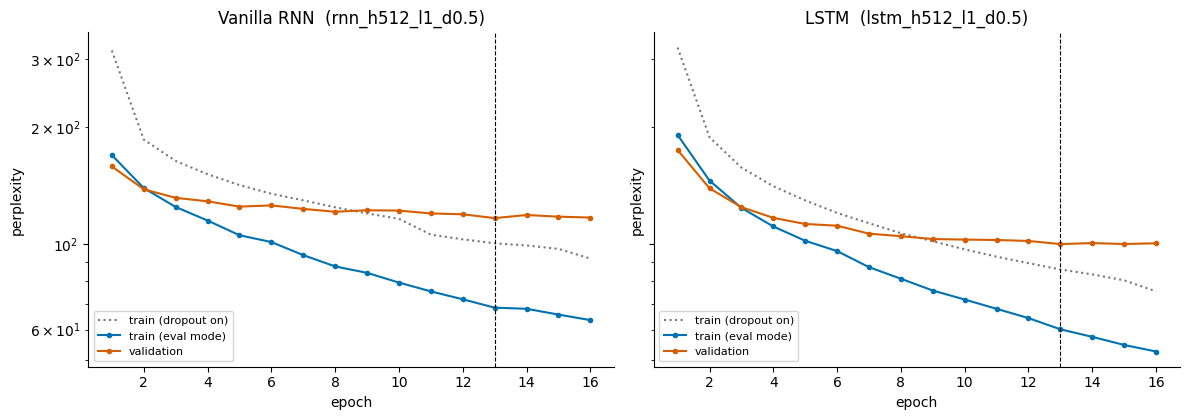

saved figure -> figures/lstm_grid_val_curves.png


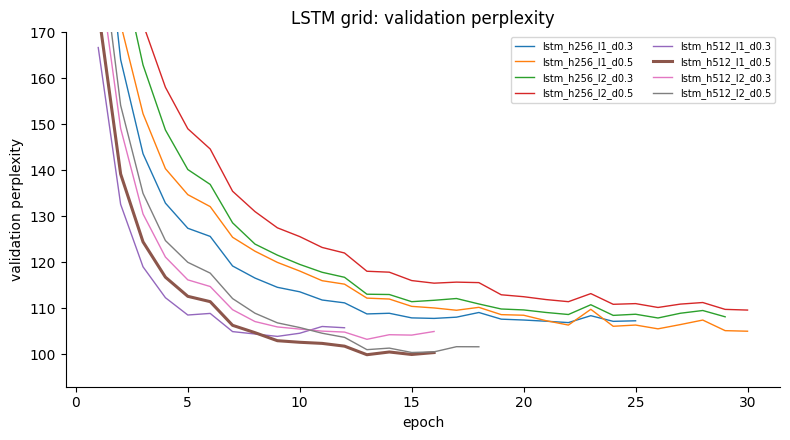

In [4]:
def curves(ax, ck, title):
    h = pd.DataFrame(ck["history"])
    ax.plot(h["epoch"], h["train_ppl_dropout"], ":", color=GREY, label="train (dropout on)")
    ax.plot(h["epoch"], h["train_ppl_eval"], "o-", color=BLUE, ms=3, label="train (eval mode)")
    ax.plot(h["epoch"], h["val_ppl"], "o-", color=ORANGE, ms=3, label="validation")
    ax.axvline(ck["best_epoch"], color="k", ls="--", lw=0.8)
    ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("perplexity"); ax.set_title(title); ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), sharey=True)
curves(axes[0], runs[best_rnn_name][2], f"Vanilla RNN  ({best_rnn_name})")
curves(axes[1], runs[best_lstm_name][2], f"LSTM  ({best_lstm_name})")
plt.tight_layout(); save_fig(fig, "rnn_training_curves.png"); plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
for name, (cfg, _, ck) in runs.items():
    if cfg["cell"] == "lstm":
        h = pd.DataFrame(ck["history"])
        ax.plot(h["epoch"], h["val_ppl"], "-", lw=2.2 if name == best_lstm_name else 1, label=name)
ax.set_ylim(top=170); ax.set_xlabel("epoch"); ax.set_ylabel("validation perplexity"); ax.set_title("LSTM grid: validation perplexity")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); save_fig(fig, "lstm_grid_val_curves.png"); plt.show()

## 4. Check of the efficient evaluation path
`iter_sentence_probs` runs every sentence through the network **once** and returns the next-word distribution at every position; it is verified against `next_word_probs()` called position by position (each call re-reads the prefix from a zero state) on 50 validation sentences.

In [5]:
def predictor(name, label=None):
    cfg, model, ck = runs[name]
    return R.RNNPredictor(model, device, name=name, cfg=cfg)


lstm, rnn = predictor(best_lstm_name), predictor(best_rnn_name)
chk = []
for pred in (rnn, lstm):
    sents = val[:50]
    max_diff, argmax_ok, n_pos = 0.0, True, 0
    for s, P in zip(sents, pred.iter_sentence_probs(sents)):
        for i in range(1, len(s)):
            q = pred.next_word_probs(s[:i])
            max_diff = max(max_diff, float(np.abs(P[i - 1] - q).max()))
            argmax_ok &= int(P[i - 1].argmax()) == int(q.argmax())
            n_pos += 1
    chk.append({"model": pred.name, "sentences": 50, "positions": n_pos, "max_abs_prob_difference": max_diff, "argmax_identical": argmax_ok})
chk = pd.DataFrame(chk)
display(chk)
assert (chk["max_abs_prob_difference"] < 1e-5).all() and chk["argmax_identical"].all()
save_table(chk, "rnn_fast_path_check.csv")

,model,sentences,positions,max_abs_prob_difference,argmax_identical
0,rnn_h512_l1_d0.5,50,838,0.000002,True
1,lstm_h512_l1_d0.5,50,838,0.000003,True


saved table  -> tables/rnn_fast_path_check.csv


## 5. Validation results
Full validation metrics of the best vanilla RNN and the best LSTM (and of the KN trigram for reference). Logged to `results/metrics.csv`.

In [6]:
def info_rnn(name):
    ck = runs[name][2]
    return {"params": ck["num_params"], "size_mb": round(mb(MODEL_DIR / f"{name}.pt"), 2)}


val_res = {}
for pred in (rnn, lstm):
    val_res[pred.name] = E.evaluate(pred, "val", vocab, log=LOG, extra=info_rnn(pred.name))
# every grid model: validation perplexity row in metrics.csv (tuning record)
for name, (cfg, model, ck) in runs.items():
    if name not in val_res and cfg["cell"] == "lstm":
        E.evaluate(R.RNNPredictor(model, device, name=name, cfg=cfg), "val", vocab, metrics="ppl", log=LOG, extra=info_rnn(name))
kn_val = pd.read_csv(TAB_DIR / "ngram_val_results.csv").set_index("model")
cols = ["ppl", "top1", "top3", "top5", "mrr", "ksr", "archaic_top1", "archaic_top5", "latency_ms"]
vt = pd.concat([kn_val.loc[["kn2", "kn3"], cols], pd.DataFrame(val_res).T[cols].astype(float)])
display(vt.round(4))

,ppl,top1,top3,top5,mrr,ksr,archaic_top1,archaic_top5,latency_ms
kn2,149.6983,0.1082,0.2015,0.2613,0.1880,0.4690,0.0351,0.1516,0.0279
kn3,136.6658,0.1275,0.2281,0.2896,0.2103,0.4789,0.0590,0.2082,0.0444
rnn_h512_l1_d0.5,116.5463,0.1300,0.2324,0.2950,0.2143,0.4879,0.0675,0.2558,6.2080
lstm_h512_l1_d0.5,99.8527,0.1426,0.2527,0.3168,0.2304,0.4990,0.0865,0.2980,7.5598


## 6. Interpolated ensemble  P = λ·P_LSTM + (1−λ)·P_KN3
For every validation token we store the probability each model gives to the actual next token; the perplexity of any λ then follows without re-running the models. λ ∈ {0, 0.1, …, 1} (λ = 0 is the pure KN trigram, λ = 1 the pure LSTM).

,0,1,2,3,4,5,6,7,8,9,10
lambda,0.000,0.100,0.200,0.30,0.400,0.500,0.600,0.700,0.800,0.900,1.000
val_ppl,136.666,118.736,110.142,104.54,100.621,97.855,95.994,94.946,94.755,95.714,99.853


best lambda on validation: 0.8
saved table  -> tables/rnn_ensemble_lambda.csv
saved figure -> figures/rnn_ensemble_lambda.png


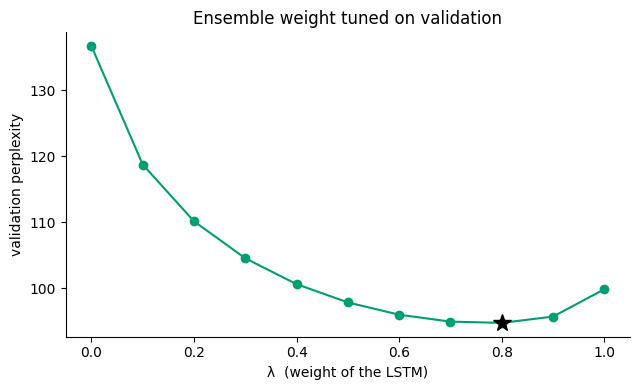

ensemble validation: ppl 94.76, top-1 0.1468, KSR 0.5029


In [7]:
kn3 = pickle.load(open(MODEL_DIR / "kn3.pkl", "rb"))
a_lstm = np.concatenate([P[np.arange(len(s) - 1), np.asarray(s[1:])] for s, P in zip(val, lstm.iter_sentence_probs(val))])
b_kn = np.array([kn3.next_word_probs(s[:i])[s[i]] for s in val for i in range(1, len(s))])
lams = np.round(np.arange(0, 1.01, 0.1), 1)
lam_df = pd.DataFrame({"lambda": lams,
                       "val_ppl": [float(np.exp(-np.mean(np.log(l * a_lstm + (1 - l) * b_kn)))) for l in lams]})
best_lam = float(lam_df.loc[lam_df["val_ppl"].idxmin(), "lambda"])
display(lam_df.round(3).T)
print(f"best lambda on validation: {best_lam}")
save_table(lam_df, "rnn_ensemble_lambda.csv")
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(lam_df["lambda"], lam_df["val_ppl"], "o-", color=GREEN)
ax.plot(best_lam, lam_df["val_ppl"].min(), "*", color="k", ms=13)
ax.set_xlabel("λ  (weight of the LSTM)"); ax.set_ylabel("validation perplexity"); ax.set_title("Ensemble weight tuned on validation")
plt.tight_layout(); save_fig(fig, "rnn_ensemble_lambda.png"); plt.show()

ens = R.Interpolated(lstm, kn3, best_lam, name=f"ensemble_{best_lstm_name}+kn3")
ens_val = E.evaluate(ens, "val", vocab, log=LOG, extra={"params": info_rnn(best_lstm_name)["params"] + ngram_info["kn3"]["params"],
                                                       "size_mb": round(info_rnn(best_lstm_name)["size_mb"] + ngram_info["kn3"]["size_mb"], 2)})
print(f"ensemble validation: ppl {ens_val['ppl']:.2f}, top-1 {ens_val['top1']:.4f}, KSR {ens_val['ksr']:.4f}")

## 7. Test set (evaluated once)
Best vanilla RNN, best LSTM and the ensemble, with the KN bigram and trigram test results of `03_ngram.ipynb`. (To analyse the KN trigram by position/word group, its test targets are scored once more *without logging*; the numbers are asserted to be identical to the earlier logged ones.)

In [8]:
test_res, details = {}, {}
for pred in (rnn, lstm):
    r = E.evaluate(pred, EVAL_SPLIT, vocab, log=LOG, details=True, extra=info_rnn(pred.name))
    details[pred.name] = r.pop("details"); test_res[pred.name] = r
ens_info = {"params": info_rnn(best_lstm_name)["params"] + ngram_info["kn3"]["params"],
            "size_mb": round(info_rnn(best_lstm_name)["size_mb"] + ngram_info["kn3"]["size_mb"], 2)}
r = E.evaluate(ens, EVAL_SPLIT, vocab, log=LOG, details=True, extra=ens_info)
details[ens.name] = r.pop("details"); test_res[ens.name] = r

# KN trigram: re-score for per-target details only (log=False) and check it reproduces the logged test numbers
r = E.evaluate(kn3, EVAL_SPLIT, vocab, log=False, details=True)
details["kn3"] = r.pop("details"); kn3_res = r
if not DRY:
    logged = pd.read_csv(TAB_DIR / "ngram_test_results.csv").set_index("model")
    for k in ("ppl", "top1", "top3", "top5", "mrr", "ksr", "archaic_top1", "archaic_top5"):
        assert abs(kn3_res[k] - logged.loc["kn3", k]) < 1e-9, k
    print("KN-3 re-scoring reproduces the logged test numbers exactly.")

kn_rows = {}
for nm in ("kn2", "kn3"):
    if DRY:
        kn_rows[nm] = {k: kn_val.loc[nm, k] for k in cols}
    else:
        kn_rows[nm] = logged.loc[nm, cols].to_dict()
    kn_rows[nm].update(ngram_info[nm])
names = {"kn2": "KN bigram", "kn3": "KN trigram", best_rnn_name: "Vanilla RNN", best_lstm_name: "LSTM", ens.name: "Ensemble (LSTM+KN3)"}
rows = []
for key, label in names.items():
    d = kn_rows[key] if key in kn_rows else test_res[key]
    rows.append({"model": label, "run": key, **{k: float(d[k]) for k in cols}, "params": d["params"], "size_mb": d["size_mb"]})
final = pd.DataFrame(rows)
final["params_M"] = (final["params"] / 1e6).round(2)
display(final.round(4))
save_table(final, "rnn_test_results.csv")
print(f"(KN rows: 'params' = stored n-gram types; ensemble lambda = {best_lam})")

KN-3 re-scoring reproduces the logged test numbers exactly.


,model,run,ppl,top1,top3,top5,mrr,ksr,archaic_top1,archaic_top5,latency_ms,params,size_mb,params_M
0,KN bigram,kn2,147.3810,0.1077,0.1986,0.2554,0.1856,0.4673,0.0452,0.1760,0.0283,253747,3.5754,0.25
1,KN trigram,kn3,134.6814,0.1261,0.2246,0.2843,0.2074,0.4771,0.0651,0.2164,0.0439,818168,17.9921,0.82
2,Vanilla RNN,rnn_h512_l1_d0.5,112.9411,0.1278,0.2292,0.2921,0.2113,0.4876,0.0843,0.2786,6.7674,8073081,32.3000,8.07
3,LSTM,lstm_h512_l1_d0.5,97.5686,0.1387,0.2482,0.3118,0.2259,0.4977,0.0985,0.3238,7.2687,9649017,38.6000,9.65
4,Ensemble (LSTM+KN3),ensemble_lstm_h512_l1_d0.5+kn3,92.8408,0.1431,0.2552,0.3198,0.2316,0.5020,0.0948,0.3209,7.6854,10467185,56.5900,10.47


saved table  -> tables/rnn_test_results.csv
(KN rows: 'params' = stored n-gram types; ensemble lambda = 0.8)


## 8. Comparison figures (test)

saved figure -> figures/rnn_test_comparison.png


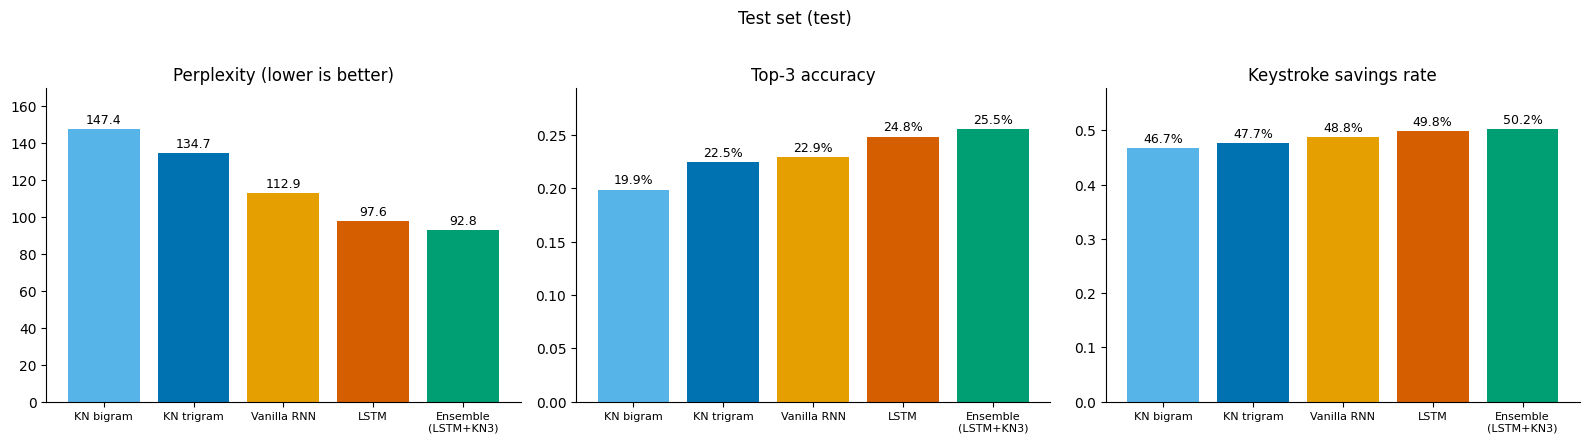

In [9]:
order = ["KN bigram", "KN trigram", "Vanilla RNN", "LSTM", "Ensemble (LSTM+KN3)"]
colors = ["#56B4E9", BLUE, "#E69F00", ORANGE, GREEN]
f = final.set_index("model").loc[order]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
for ax, col, ttl, fmt in zip(axes, ["ppl", "top3", "ksr"], ["Perplexity (lower is better)", "Top-3 accuracy", "Keystroke savings rate"],
                             ["{:.1f}", "{:.1%}", "{:.1%}"]):
    bars = ax.bar(range(len(order)), f[col], color=colors)
    ax.bar_label(bars, labels=[fmt.format(v) for v in f[col]], padding=2, fontsize=9)
    ax.set_xticks(range(len(order))); ax.set_xticklabels([o.replace(" (", "\n(") for o in order], fontsize=8)
    ax.set_title(ttl)
    ax.set_ylim(0, f[col].max() * 1.15)
plt.suptitle(f"Test set ({EVAL_SPLIT})" if not DRY else "VALIDATION (dry run)", y=1.02)
plt.tight_layout(); save_fig(fig, "rnn_test_comparison.png"); plt.show()

model,KN trigram,LSTM
position,,
1,0.0774,0.0774
2,0.1729,0.1767
3-5,0.1387,0.1540
6-10,0.1320,0.1472
11-20,0.1224,0.1377
21+,0.1164,0.1289


saved table  -> tables/rnn_top1_by_position.csv


saved figure -> figures/rnn_top1_by_position.png


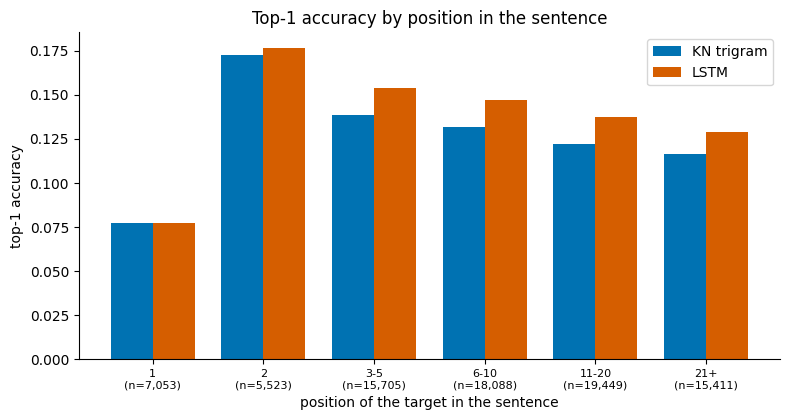

In [10]:
# top-1 accuracy by position of the target in the sentence (word targets; position 1 = first token after <s>)
buckets = [("1", 1, 1), ("2", 2, 2), ("3-5", 3, 5), ("6-10", 6, 10), ("11-20", 11, 20), ("21+", 21, 10_000)]
rows = []
for key, label in (("kn3", "KN trigram"), (lstm.name, "LSTM")):
    d = details[key]
    for lab, lo, hi in buckets:
        m = (d["pos"] >= lo) & (d["pos"] <= hi)
        rows.append({"model": label, "position": lab, "n_targets": int(m.sum()), "top1": float((d["rank"][m] == 1).mean())})
pos_df = pd.DataFrame(rows)
display(pos_df.pivot(index="position", columns="model", values="top1").loc[[b[0] for b in buckets]].round(4))
save_table(pos_df, "rnn_top1_by_position.csv")

fig, ax = plt.subplots(figsize=(8, 4.3))
w = 0.38
x = np.arange(len(buckets))
for off, (label, c) in zip((-w / 2, w / 2), (("KN trigram", BLUE), ("LSTM", ORANGE))):
    g = pos_df[pos_df["model"] == label].set_index("position").loc[[b[0] for b in buckets]]
    ax.bar(x + off, g["top1"], w, color=c, label=label)
ax.set_xticks(x); ax.set_xticklabels([f"{b[0]}\n(n={int(pos_df[(pos_df['model']=='LSTM')&(pos_df['position']==b[0])]['n_targets'].iloc[0]):,})" for b in buckets], fontsize=8)
ax.set_xlabel("position of the target in the sentence"); ax.set_ylabel("top-1 accuracy"); ax.legend()
ax.set_title("Top-1 accuracy by position in the sentence")
plt.tight_layout(); save_fig(fig, "rnn_top1_by_position.png"); plt.show()

not in vocabulary: []


,KN trigram,LSTM,n_targets
group,,,
all other targets (no verb form),0.1261,0.1388,80699
hath / hast / doth / dost / art / wilt / shalt,0.1189,0.1321,530
thou / thee / thy / thine,0.1240,0.1860,1677
you / your,0.2002,0.2080,1793


saved table  -> tables/rnn_top1_archaic_groups.csv


saved figure -> figures/rnn_top1_archaic_groups.png


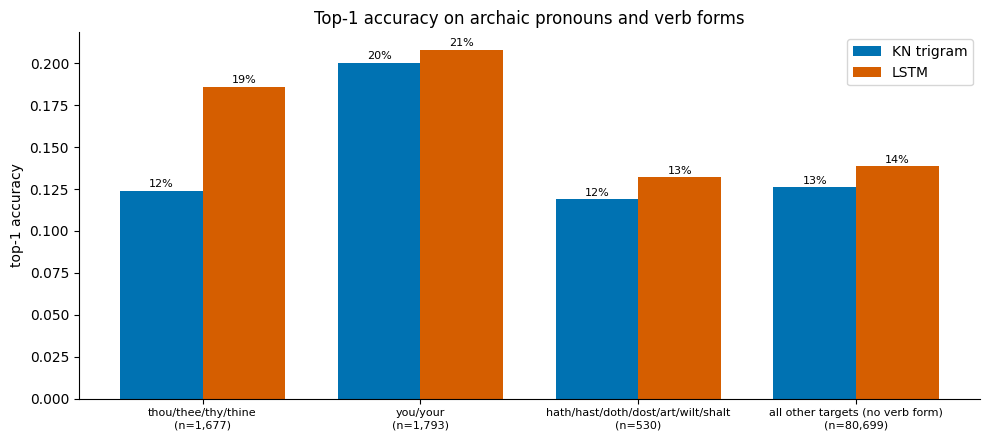

In [11]:
# archaic pronoun / verb forms
groups = {"thou / thee / thy / thine": ["thou", "thee", "thy", "thine"],
          "you / your": ["you", "your"],
          "hath / hast / doth / dost / art / wilt / shalt": ["hath", "hast", "doth", "dost", "art", "wilt", "shalt"]}
verbs = set(groups["hath / hast / doth / dost / art / wilt / shalt"])
missing = [w for ws in groups.values() for w in ws if w not in vocab.stoi]
print("not in vocabulary:", missing)


def mask_for(d, words):
    ids = {vocab.stoi[w] for w in words if w in vocab.stoi}
    return np.isin(d["target"], list(ids))


rows = []
for key, label in (("kn3", "KN trigram"), (lstm.name, "LSTM")):
    d = details[key]
    sel = {**{g: mask_for(d, ws) for g, ws in groups.items()}, "all other targets (no verb form)": ~mask_for(d, verbs)}
    for g, m in sel.items():
        rows.append({"model": label, "group": g, "n_targets": int(m.sum()), "top1": float((d["rank"][m] == 1).mean())})
grp = pd.DataFrame(rows)
display(grp.pivot(index="group", columns="model", values="top1").round(4).join(grp[grp["model"] == "LSTM"].set_index("group")["n_targets"]))
save_table(grp, "rnn_top1_archaic_groups.csv")

fig, ax = plt.subplots(figsize=(10, 4.5))
order_g = list(groups) + ["all other targets (no verb form)"]
x = np.arange(len(order_g))
for off, (label, c) in zip((-w / 2, w / 2), (("KN trigram", BLUE), ("LSTM", ORANGE))):
    g = grp[grp["model"] == label].set_index("group").loc[order_g]
    bars = ax.bar(x + off, g["top1"], w, color=c, label=label)
    ax.bar_label(bars, labels=[f"{v:.0%}" for v in g["top1"]], fontsize=8, padding=1)
n_lbl = grp[grp["model"] == "LSTM"].set_index("group").loc[order_g, "n_targets"]
ax.set_xticks(x); ax.set_xticklabels([f"{g.replace(' / ', '/')}\n(n={n:,})" for g, n in zip(order_g, n_lbl)], fontsize=8)
ax.set_ylabel("top-1 accuracy"); ax.legend(); ax.set_title("Top-1 accuracy on archaic pronouns and verb forms")
plt.tight_layout(); save_fig(fig, "rnn_top1_archaic_groups.png"); plt.show()

## 9. Qualitative: the same ten prefixes as `ngram_examples.csv`
Top-5 *word* suggestions (probabilities from the full distribution) of the KN trigram, the LSTM and the ensemble.

In [12]:
ex = pd.read_csv(TAB_DIR / "ngram_examples.csv")
cand = E.word_ids(vocab)
models_q = {"KN trigram": kn3, "LSTM": lstm, "Ensemble": ens}


def topk(model, ctx, true_id, k=5):
    p = model.next_word_probs(ctx)
    pc = p[cand]
    top = cand[np.lexsort((cand, -pc))[:k]]
    rank = 1 + int((pc > p[true_id]).sum() + ((pc == p[true_id]) & (cand < true_id)).sum())
    return " | ".join(f"{vocab.itos[t]} ({p[t]:.2f})" for t in top), rank


rows = []
for _, r in ex.iterrows():
    ctx = [vocab.bos_id] + vocab.encode(str(r["prefix"]).split())
    true_id = vocab.stoi[r["actual_next"]]
    row = {"kind": r["kind"], "play": r["play"], "prefix": " ".join(str(r["prefix"]).split()[-9:]), "actual_next": r["actual_next"]}
    for lab, m in models_q.items():
        s, rk = topk(m, ctx, true_id)
        row[f"{lab} top-5"] = s
        row[f"{lab} rank"] = rk
    rows.append(row)
qual = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 80); pd.set_option("display.width", 300)
display(qual)
save_table(qual, "rnn_examples.csv")

,kind,play,prefix,actual_next,KN trigram top-5,KN trigram rank,LSTM top-5,LSTM rank,Ensemble top-5,Ensemble rank
0,archaic next word,antony_and_cleopatra,i have seen thee fight when i have envied,thy,the (0.03) | his (0.03) | him (0.03) | against (0.03) | of (0.01),29,my (0.19) | thee (0.11) | the (0.10) | him (0.05) | her (0.04),6,my (0.16) | the (0.09) | thee (0.09) | him (0.05) | her (0.04),6
1,archaic next word,twelfth_night_or_what_you_will,"alas , poor fool , how have they baffled",thee,here (0.05) | of (0.01) | and (0.01) | to (0.01) | in (0.01),37,here (0.03) | with (0.01) | thus (0.01) | there (0.01) | in (0.01),18,here (0.04) | with (0.01) | thus (0.01) | in (0.01) | there (0.01),21
2,archaic next word,second_part_of_king_henry_the_sixth,"my lord ,",i'll,i (0.14) | and (0.07) | you (0.05) | my (0.04) | that (0.03),19,i (0.29) | my (0.06) | you (0.05) | we (0.03) | sir (0.03),10,i (0.26) | my (0.05) | you (0.05) | and (0.03) | sir (0.02),11
3,archaic next word,tempest,"king's ship , invisible as thou art : there",shalt,is (0.46) | shall (0.10) | are (0.06) | was (0.01) | be (0.01),207,is (0.40) | was (0.04) | are (0.04) | art (0.02) | be (0.02),88,is (0.41) | are (0.04) | was (0.04) | shall (0.03) | be (0.02),94
4,archaic next word,antony_and_cleopatra,'tis one of those odd tricks which,sorrow,i (0.05) | is (0.03) | the (0.02) | you (0.02) | he (0.02),243,i (0.14) | we (0.09) | is (0.07) | he (0.05) | they (0.04),342,i (0.13) | we (0.07) | is (0.06) | he (0.04) | you (0.03),340
5,ordinary next word,twelfth_night_or_what_you_will,"you are mad indeed , if you be no",better,more (0.21) | less (0.04) | better (0.04) | great (0.03) | other (0.02),3,more (0.06) | man (0.04) | less (0.03) | matter (0.03) | further (0.02),6,more (0.09) | man (0.03) | less (0.03) | matter (0.02) | better (0.02),5
6,ordinary next word,second_part_of_king_henry_the_sixth,"john , it will be stinking law , for",his,i (0.09) | the (0.07) | my (0.04) | he (0.04) | a (0.03),13,i (0.07) | the (0.06) | that (0.05) | this (0.03) | they (0.03),13,i (0.07) | the (0.06) | that (0.05) | this (0.03) | all (0.03),13
7,ordinary next word,tempest,"i visit young ferdinand , whom they suppose is",drown'd,a (0.03) | the (0.03) | not (0.03) | in (0.02) | to (0.02),1533,not (0.04) | the (0.01) | but (0.01) | so (0.01) | in (0.01),773,not (0.04) | the (0.01) | but (0.01) | a (0.01) | in (0.01),833
8,ordinary next word,tempest,"prithee , say",on,i (0.19) | you (0.10) | they (0.04) | what (0.04) | no (0.02),55,you (0.23) | i (0.08) | thou (0.06) | what (0.04) | not (0.03),42,you (0.21) | i (0.10) | thou (0.05) | what (0.04) | not (0.03),45
9,ordinary next word,second_part_of_king_henry_the_sixth,by devilish policy art thou grown great,and,in (0.02) | and (0.02) | ones (0.01) | men (0.01) | of (0.01),2,to (0.03) | and (0.02) | men (0.01) | of (0.01) | in (0.01),2,to (0.02) | and (0.02) | men (0.01) | in (0.01) | of (0.01),2


saved table  -> tables/rnn_examples.csv


## 10. Sampled sentences (for the presentation)
Ancestral sampling from `<s>` (never sampling `<s>` or `<unk>`), at most 40 tokens, seeds fixed. Temperature 0.7 sharpens the distribution, 1.0 samples from the model as is. Case is restored with the train case map.

In [13]:
case_map = D.load_case_map()
rows = []
for label, model in (("LSTM", lstm), ("KN trigram", kn3)):
    for T in (0.7, 1.0):
        rng = np.random.default_rng(42)
        for i in range(10):
            toks = vocab.decode(G.sample_sentence(model, vocab, T, rng))
            rows.append({"model": label, "temperature": T, "sample": D.restore_case(toks, case_map)})
samples = pd.DataFrame(rows)
for (label, T), g in samples.groupby(["model", "temperature"], sort=False):
    print(f"\n--- {label}, temperature {T} ---")
    for s in g["sample"]:
        print("  ", s)
save_table(samples, "rnn_samples.csv")


--- LSTM, temperature 0.7 ---
   Let me hear it.
   Here comes the Duke.
   Come, come, come.
   Or there?
   God bless you, good sir!
   Ha!
   What, is this lord a daughter?
   My master is not my brother.
   The King's part of Rome, that I have found of all my father's power, and, have I been some in, I will have no fall of but so.
   I may not be with you.

--- LSTM, temperature 1.0 ---
   Hence, cur!
   Ambassadors with suits.
   No fault of valour to my music.
   'tis strange.
   He'll pay you with the place: give Arcite to that Duke, and let it first hear those enemy to evil prisoners, I never will than, though all myself were done, and you us say for
   After her?
   Will I see you?
   This is the cause of Caesar: let his dam be; and an ill did men, yet we are men that she is to invest 'em with your wronger; our fortunes for the weighty business, not
   Did I perceive by these things that would give you more?
   What, in our friends a battle?

--- KN trigram, temperature 0.7 -

## Summary of findings

1. **Setup and fairness:** vanilla RNN and LSTM use the same vocabulary, loader and evaluator as the n-grams, sentence-only context (zero state at `<s>`), whole sentences batched without truncation. The softmax includes `<s>`; the networks put on average 1.6e-5 (LSTM) / 2.1e-5 (RNN) probability on it versus 6.6e-7 for the KN trigram – negligible for all of them. The one-pass evaluation path matches `next_word_probs()` position by position on 50 validation sentences (max probability difference 3e-6, identical argmax; this required switching off TF32 at evaluation time – with TF32 the difference was 3e-4).
2. **LSTM tuning (validation only, full grid, 48 min total on an RTX 4050):** the best configuration is **512 hidden, 1 layer, dropout 0.5** (validation perplexity 99.85). Larger hidden size and dropout 0.5 helped; a second layer did not (512×2: 100.3 / 103.2). The best configuration lies on the edge of the grid (largest hidden size, largest dropout), so a wider grid might gain a little; the 256-hidden models were still improving when they hit the 30-epoch cap.
3. **Vanilla RNN** with the same size and depth: validation perplexity 116.55 (dropout 0.5; 118.65 with 0.3) – better than the KN trigram (136.7) but 17 % above the LSTM.
4. **Test perplexity (evaluated once):** KN bigram 147.4 → KN trigram 134.7 → vanilla RNN 112.9 → **LSTM 97.6** → ensemble 92.8. The LSTM is 27.6 % below the KN trigram and 33.8 % below the bigram; the RNN is 16.1 % below the trigram.
5. **Ensemble:** λ = 0.8 on validation (94.76 vs 99.85 for the LSTM alone and 136.7 for KN-3); on test the interpolation with the KN trigram lowers perplexity by another 4.9 % (92.8) and gives the best top-3 (25.5 %), top-5 (32.0 %) and KSR (50.2 %).
6. **Word prediction on test:** top-1 / 3 / 5 = KN trigram 12.6 / 22.5 / 28.4 %, RNN 12.8 / 22.9 / 29.2 %, LSTM 13.9 / 24.8 / 31.2 %, ensemble 14.3 / 25.5 / 32.0 %. The accuracy gains (+1.3 points top-1 for the LSTM) are much smaller than the perplexity gain: perplexity is also driven by how well the models score punctuation, `</s>` and rare words. Keystroke savings: 47.7 % → 49.8 % (LSTM) / 50.2 % (ensemble).
7. **Where the LSTM helps:** position 1 is identical (7.7 % – no context), the gain appears from position 3 on (+1.5 points at positions 3-5, 11-20 and 21+); for **thou / thee / thy / thine** the LSTM's top-1 is 18.6 % vs 12.4 % for KN-3 (+6.2 points, n = 1,677), whereas for you / your (20.8 vs 20.0 %), the verb forms hath / hast / doth / dost / art / wilt / shalt (13.2 vs 11.9 %, n = 530) and all other targets (13.9 vs 12.6 %) the gap is ~1 point. Overall archaic-keyword top-1 / top-5: 9.9 / 32.4 % (LSTM) vs 6.5 / 21.6 % (KN-3); the ensemble is slightly worse than the LSTM there because the KN component dilutes the archaic predictions.
8. **Cost:** the n-grams answer in 0.03–0.04 ms per call, the RNN/LSTM in 6.8–7.3 ms on CPU (a stateless call re-reads the prefix; the cost is dominated by the 14.7k-word output layer), still fine for a keyboard but ~170× slower. Size: KN trigram 0.82M stored n-gram types / 18 MB on disk, KN bigram 0.25M / 3.6 MB, vanilla RNN 8.1M parameters / 32 MB, LSTM 9.6M / 38.6 MB, ensemble 10.5M / 56.6 MB (n-gram "parameters" = stored n-gram types).
9. **Qualitative:** the examples and samples show the LSTM producing fluent short sentences and archaic forms (*'tis strange*, *Hence, cur!*) while the KN trigram drifts into word salad after a few words, particularly at temperature 1.0; at temperature 0.7 both repeat common short sentences.
10. **Caveats:** single seed (42) and single runs, no confidence intervals; training used the default cuDNN TF32 mode while evaluation uses full fp32; latency is a CPU wall-clock measurement on one laptop; the KN trigram was re-scored once more on test (without logging) to get per-target details and reproduced its logged numbers exactly.